# Wavelet-PINN for the 2D elliptic interface problem (gear / settings-icon interface)
Hard-geometry stress test: a closed gear with 8 sharp, deep teeth (~44% radial depth) -- much more complex than the flower. Same decomposed AD-free solver; only the geometry changes (mesh-free). The level set is windowed-smooth (deep teeth need a non-harmonic $\phi$), so the source $f=-\Delta\phi$ varies in space and is computed exactly by autograd. The finest wavelets are placed only in the teeth annulus (banded multiresolution refinement).

In [1]:
from config import *
from EllipticInterface import *
from Wfamily import *
from Model import *
import math

family_len: 4764


In [2]:
NF = len_family; n = 2*NF + 2
wi, wb, tik = 10.0, 10.0, 1e-10
def blk(rows, cM=None, cP=None, bM=None, bP=None):
    B = torch.zeros(rows, n)
    if cM is not None: B[:, :NF] = cM
    if cP is not None: B[:, NF:2*NF] = cP
    if bM is not None: B[:, 2*NF] = bM
    if bP is not None: B[:, 2*NF+1] = bP
    return B
A = torch.cat([
    blk(len(x_in),  cM=-a_in*Lin), blk(len(x_out), cP=-a_out*Lout),
    math.sqrt(wi)*blk(len(x_if), cP=Wif, cM=-Wif, bP=1., bM=-1.),
    math.sqrt(wi)*blk(len(x_if), cP=a_out*DnIf, cM=-a_in*DnIf),
    math.sqrt(wb)*blk(len(x_bc), cP=Wbc, bP=1.)], 0)
b = torch.cat([torch.tensor(f_in), torch.tensor(f_out),
    torch.zeros(len(x_if)), torch.zeros(len(x_if)), math.sqrt(wb)*torch.tensor(u_bc)]).unsqueeze(1)
s = A.norm(dim=0).clamp_min(1e-30)
theta = (torch.linalg.lstsq(torch.cat([A/s, math.sqrt(tik)*torch.eye(n)]), torch.cat([b, torch.zeros(n,1)]), driver='gelsd').solution.squeeze(1))/s
cM, cP, bM, bP = theta[:NF], theta[NF:2*NF], theta[2*NF], theta[2*NF+1]

rho = 1000 | NF = 4764
relL2   = 1.015e-03
MSE     = 7.467e-09
RMSE    = 8.641e-05
MAE     = 6.579e-05
Linf    = 5.057e-04
relLinf = 1.672e-03
kinkErr = 2.108e-02


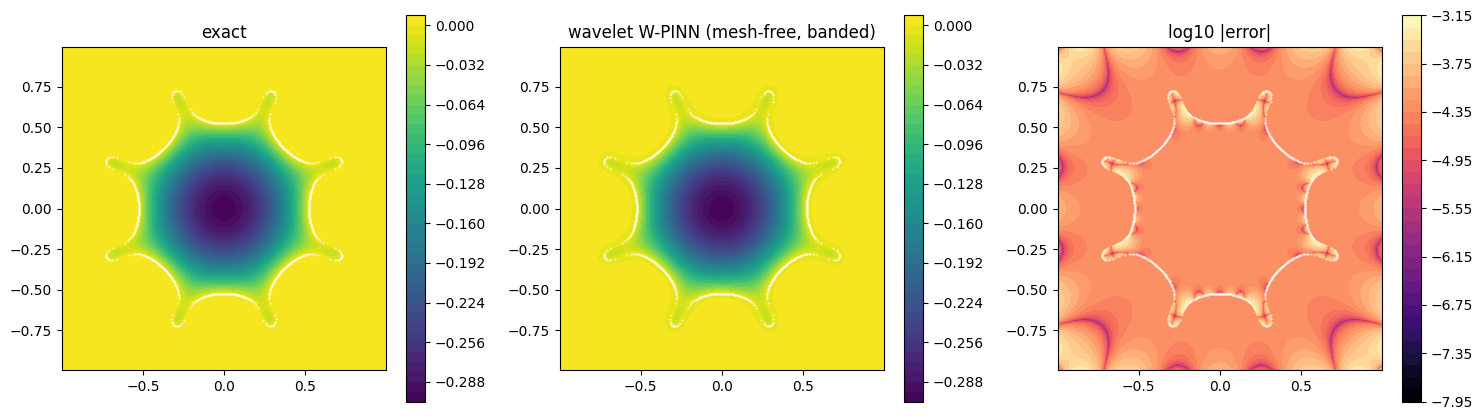

In [3]:
um = (Wtest@cM + bM).numpy(); up = (Wtest@cP + bP).numpy()
pred = np.where(inside_test, um, up); err = pred - u_exact_te
relL2 = np.linalg.norm(err)/np.linalg.norm(u_exact_te)
MSE = np.mean(err**2); RMSE = math.sqrt(MSE); MAE = np.mean(np.abs(err))
Linf = np.max(np.abs(err)); relLinf = Linf/np.max(np.abs(u_exact_te))
kink = np.max(np.abs(((DnIf@cP)-(DnIf@cM)).numpy() - jump_dn))
print(f'rho = {rho:g} | NF = {NF}')
print(f'relL2   = {relL2:.3e}')
print(f'MSE     = {MSE:.3e}')
print(f'RMSE    = {RMSE:.3e}')
print(f'MAE     = {MAE:.3e}')
print(f'Linf    = {Linf:.3e}')
print(f'relLinf = {relLinf:.3e}')
print(f'kinkErr = {kink:.3e}')
PR = pred.reshape(Xt.shape); UE = u_exact_te.reshape(Xt.shape); ER = np.abs(PR-UE)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
for a_, Z, ttl, cm in [(ax[0],UE,'exact','viridis'),(ax[1],PR,'wavelet W-PINN (mesh-free, banded)','viridis'),(ax[2],np.log10(ER+1e-16),'log10 |error|','magma')]:
    c = a_.contourf(Xt, Yt, Z, 40, cmap=cm); a_.plot(x_if, y_if, 'w.', ms=0.7); a_.set_aspect('equal'); a_.set_title(ttl); fig.colorbar(c, ax=a_)
plt.tight_layout(); plt.savefig('sol.png', dpi=120); plt.show()